<a href="https://colab.research.google.com/github/CAMI2-bit/INVESTIGACION-DE-OPERACIONES-/blob/main/Networkx_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="#800020">ALGORITMO DE ÁRBOL DE EXPANSIÓN MÍNIMA</font>

---

El **algoritmo de árbol de expansión mínima** enlaza los **nodos** de una red (en forma *directa* o *indirecta*) con la **mínima longitud** de las ramas enlazantes.

> **Objetivo clave:** Conectar todos los puntos de la red sin formar ciclos, optimizando la distancia o costo total.

---

### <font color="#2C3E50">Aplicación Característica</font>

Una aplicación característica se encuentra en la **construcción de carreteras pavimentadas** que unen varias ciudades o comunidades, asegurando el menor costo de infraestructura.

<div style="background-color: #f8f9fa; border-left: 5px solid #800020; padding: 12px; margin: 10px 0; border-radius: 4px;">
<b> Aspectos Importantes a Recordar:</b>
<ul>
  <li><b>Nodos:</b> Puntos o vértices de la red (ej. ciudades, servidores).</li>
  <li><b>Ramas / Aristas:</b> Conexiones directas con un costo o longitud asociada.</li>
  <li><b>Criterio de Optimización:</b> Minimizar la suma total de las longitudes.</li>
</ul>
</div>

## <font color="#800020">Algoritmo de Resolución Paso a Paso</font>
---

* **Paso 0.** El conjunto inicial se define como $C_0 = \emptyset$ y $\overline{C}_0 = N$.


* **Paso 1.** Comenzar con *cualquier* nodo en el conjunto $\overline{C}_0$ no conectado (o **"inconexo"**), e igualar $C_1 = \{i\}$, con lo que $\overline{C}_1 = N - \{i\}$. Igualar $k = 2$.


* **Paso general $k$.** Seleccionar un nodo $j^*$ en el conjunto no conectado $\overline{C}_{k-1}$ que produzca el **arco más corto** a un nodo en el conjunto conectado $C_{k-1}$. Enlazar a $j^*$ en forma permanente con $C_{k-1}$ y sacarlo de $\overline{C}_{k-1}$, esto es:

$$C_k = C_{k-1} + \{j^*\}, \quad \overline{C}_k = \overline{C}_{k-1} - \{j^*\}$$


>  **Criterio de Parada:** Si el conjunto $\overline{C}_k$ de nodos no conectados está **vacío**, detenerse. En cualquier otro caso, igualar $k = k + 1$ y repetir el paso.

</div>

### <font color="#008080">Codigo Arbol de Expansion</font>
Primero importamos `networkx` para manejar la red y `matplotlib` para dibujarla.

Después creamos la variable `G_mst` usando `nx.Graph()`, que sirve para definir un **grafo no dirigido** (es decir, una red donde las conexiones no tienen una sola dirección y se pueden recorrer hacia ambos lados).

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

#Creamos el grafo no dirigido
G_mst = nx.Graph()


Guardamos todas las uniones del grafo en la lista `aristas_mst`. Cada dato tiene la estructura **`(nodo1, nodo2, distancia)`**

Luego, usamos un ciclo `for` con la función `G_mst.add_edge(u, v, weight=w)` para agregar cada conexión a la red y asignarle su peso correspondiente.


In [11]:
#Definición de las aristas y sus pesos (longitud de las ramas)
#Formato: (Nodo_Origen, Nodo_Destino, Peso)
aristas_mst = [
    (1, 2, 5), (1, 3, 1),
    (2, 3, 2), (2, 4, 7), (2, 5, 1), (2, 6, 6),
    (3, 4, 6), (3, 5, 7),
    (4, 5, 3), (4, 6, 4), (4, 7, 6),
    (5, 6, 5), (5, 7, 9),
    (6, 7, 2)
]

#Agregar aristas ponderadas al grafo
for u, v, w in aristas_mst:
    G_mst.add_edge(u, v, weight=w)

### <font color="#008080">Calcular el árbol de expansión mínima</font>

Usamos la función `nx.minimum_spanning_tree(G_mst, weight='weight')` para que **NetworkX** seleccione automáticamente las conexiones más cortas que unen todos los nodos sin formar caminos cerrados.

Después, con `.size(weight='weight')` sumamos el peso de esas conexiones seleccionadas para obtener la **longitud total mínima** de la red.

</div>

In [7]:
#Aplicar el algoritmo de Árbol de Expansión Mínima de NetworkX
mst_resultado = nx.minimum_spanning_tree(G_mst, weight='weight')
longitud_total = mst_resultado.size(weight='weight')



### <font color="#008080">Empezamos con la gráfica</font>

Usamos **`nx.spring_layout(G_mst, seed=42)`** para calcular las coordenadas de cada nodo y fijarlas en la pantalla (la opción `seed=42` evita que la red cambie de posición cada vez que ejecutes el código).

Con **`plt.figure(figsize=(9, 6))`** creamos el lienzo del gráfico ajustando el tamaño para que se vea claro y bien proporcionado.

</div>

In [8]:
#Graficar la red resaltando el árbol mínimo
pos = nx.spring_layout(G_mst, seed=42) # Posición fija para los nodos

plt.figure(figsize=(9, 6))

<Figure size 900x600 with 0 Axes>

<Figure size 900x600 with 0 Axes>

### <font color="#008080">Graficar la red y mostrar los resultados</font>

En este último bloque representamos la solución de forma visual e impresa:

* **Dibujo del grafo base:** Con `nx.draw_networkx_nodes()` y `nx.draw_networkx_labels()` trazamos los nodos en tono azul obscuro con texto blanco, mientras que `nx.draw_networkx_edges()` dibuja todas las conexiones originales en líneas grises punteadas.
* **Resaltado de la solución:** Convertimos las aristas del árbol mínimo a una lista (`aristas_del_arbol`) y las dibujamos encima con un trazo guinda más grueso (`width=3.5`).
* **Etiquetas y formato:** Extraemos las distancias con `nx.get_edge_attributes()` para colocarlas sobre cada rama con `nx.draw_networkx_edge_labels()`, ocultamos los ejes del plano (`plt.axis('off')`) y mostramos en pantalla la gráfica junto con los datos finales del peso total.

</div>

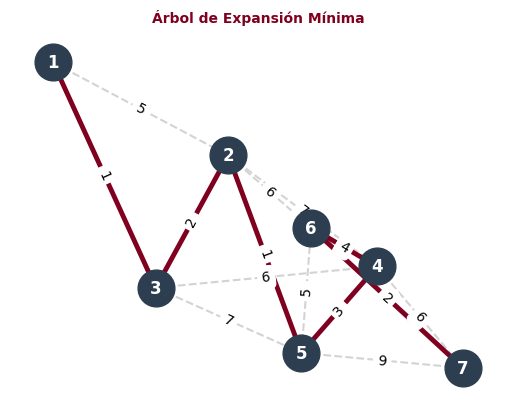

Resultados:
Aristas seleccionadas (Nodos conectados): [(1, 3), (2, 5), (2, 3), (4, 5), (4, 6), (6, 7)]
Distancia minima de la red: 13.0


In [13]:
#Dibujar nodos y todas las aristas de la red en gris
nx.draw_networkx_nodes(G_mst, pos, node_color='#2C3E50', node_size=700)
nx.draw_networkx_labels(G_mst, pos, font_color='white', font_weight='bold')
nx.draw_networkx_edges(G_mst, pos, edge_color='lightgray', style='dashed', width=1.5)

#Resaltar en color guinda las aristas que forman el árbol de expansión mínima
aristas_del_arbol = list(mst_resultado.edges())
nx.draw_networkx_edges(G_mst, pos, edgelist=aristas_del_arbol, edge_color='#800020', width=3.5)

#Mostrar las distancias de las aristas
etiquetas_pesos = nx.get_edge_attributes(G_mst, 'weight')
nx.draw_networkx_edge_labels(G_mst, pos, edge_labels=etiquetas_pesos)

plt.title("Árbol de Expansión Mínima", fontsize=10, fontweight='bold', color='#800020')
plt.axis('off')
plt.show()

#Mostrar los resultados
print("Resultados:")
print("Aristas seleccionadas (Nodos conectados):", aristas_del_arbol)
print(f"Distancia minima de la red: {longitud_total}")


# <font color="#800020">ALGORITMOS DE RUTA MÁS CORTA</font>

---

El problema de la **ruta más corta** busca determinar la trayectoria de menor distancia, costo o tiempo transcurrido desde un **nodo origen** hasta un **nodo destino** a través de una red.

> **Objetivo clave:** Encontrar el camino óptimo acumulado respetando el sentido y peso de los arcos en la red.

---

### <font color="#2C3E50">Métodos Principales de Resolución</font>

Esta sección presenta dos de los algoritmos más representativos para resolver problemas en redes tanto **cíclicas** (que contienen bucles o lazos) como **acíclicas**:

1. **El algoritmo de Dijkstra:** Determina la ruta más corta desde un único nodo origen hacia todos los demás nodos de la red (ideal cuando todos los pesos son no negativos).
2. **El algoritmo de Floyd:** Determina la ruta más corta entre **todos los pares de nodos** de la red de manera simultánea.

<div style="background-color: #f8f9fa; border-left: 5px solid #800020; padding: 12px; margin: 10px 0; border-radius: 4px;">
<b> Aspectos Importantes:</b>
<ul>
  <li><b>Red Dirigida:</b> Los arcos poseen un sentido específico (origen $\rightarrow$ destino) que se debe respetar.</li>
  <li><b>Distancia Acumulada:</b> Se busca minimizar la suma de las etiquetas de costo o distancia a lo largo del trayecto.</li>
  <li><b>Aplicación en NetworkX:</b> Para este tutorial utilizaremos el algoritmo de Dijkstra para encontrar el camino entre el nodo inicial y el nodo final.</li>
</ul>
</div>

# <font color="#800020">ALGORITMO DE DIJKSTRA</font>

---

El **algoritmo de Dijkstra** tiene como objetivo determinar las rutas más cortas desde un **nodo fuente** (origen) hacia todos los demás nodos de la red.

> **Objetivo clave:** Determinar de forma iterativa las distancias mínimas desde la fuente actualizando etiquetas de costo acumulado hasta que todas sean permanentes.

---

### <font color="#2C3E50">Mecanismo de Etiquetado</font>

Sea $u_i$ la distancia más corta desde el nodo fuente hasta el nodo $i$, y $d_{ij} \geq 0$ la longitud del arco $(i, j)$. La etiqueta de un nodo posterior $j$ se define como:

$$[u_j, i] = [u_i + d_{ij}, i]$$

Donde el primer término es la **distancia acumulada** y el segundo indica el **nodo predecesor**.

Las etiquetas en este algoritmo se dividen en dos clases:
* **Temporales:** Se pueden modificar si se encuentra un camino más corto hacia ese nodo.
* **Permanentes:** Se fijan definitivamente cuando se garantiza que no existe una mejor ruta.

---

### <font color="#2C3E50">Pasos del Algoritmo</font>

1. **Paso 0:** Etiquetar el nodo fuente con la etiqueta permanente $[0, -]$ e igualar $i = 1$.
2. **Paso $i$ (a):** Calcular las etiquetas temporales $[u_i + d_{ij}, i]$ para cada nodo $j$ alcanzable desde $i$ que aún no sea permanente. Si el nodo ya tenía una etiqueta $[u_j, k]$ y se cumple que $u_i + d_{ij} < u_j$, se sustituye la etiqueta por $[u_i + d_{ij}, i]$.
3. **Paso $i$ (b):** Si todos los nodos tienen etiqueta permanente, el algoritmo **se detiene**. En caso contrario, se selecciona la etiqueta temporal con la menor distancia acumulada, se convierte en permanente y se repite el paso $i$.

<div style="background-color: #f8f9fa; border-left: 5px solid #800020; padding: 12px; margin: 10px 0; border-radius: 4px;">
<b>Aspectos Importantes:</b>
<ul>
  <li><b>Etiqueta Inicial:</b> El nodo de origen comienza siempre como $[0, -]$ (distancia cero y sin predecesor).</li>
  <li><b>Condición de Parada:</b> El algoritmo finaliza únicamente cuando todos los nodos alcanzables han fijado su etiqueta como permanente.</li>
  <li><b>NetworkX:</b> La función <code>nx.shortest_path()</code> implementa esta lógica interna de Dijkstra automáticamente.</li>
</ul>
</div>

### <font color="#008080">Importar librerías y crear el grafo dirigido</font>

Primero importamos `networkx` para construir la red y `matplotlib` para dibujarla.

A diferencia del ejercicio anterior, aquí usamos **`nx.DiGraph()`** para crear un **grafo dirigido**, lo que significa que el sentido de las flechas sí importa al recorrer las conexiones.

In [15]:
import networkx as nx
import matplotlib.pyplot as plt

#Crear el grafo dirigido usando
G_sp = nx.DiGraph()

### <font color="#008080">Definir y agregar las conexiones dirigidas</font>

Guardamos las flechas de la red en la lista `aristas_sp`. Cada elemento indica el camino con la estructura **`(origen, destino, peso)`**.

Con el ciclo `for` y la función `G_sp.add_edge(u, v, weight=w)` agregamos cada arco respetando su dirección y distancia. Al final, confirmamos con un `print` la cantidad total de nodos y conexiones cargadas.


In [16]:
#Definición de las aristas dirigidas (Nodo_Origen, Nodo_Destino, Peso)
aristas_sp = [
    (1, 2, 5), (1, 3, 1),
    (2, 3, 2), (2, 4, 7), (2, 5, 1), (2, 6, 6),
    (3, 4, 6), (3, 5, 7),
    (4, 5, 3), (4, 6, 4), (4, 7, 6),
    (5, 6, 5), (5, 7, 9),
    (6, 7, 2)
]

In [18]:
#Agregar aristas ponderadas
for u, v, w in aristas_sp:
    G_sp.add_edge(u, v, weight=w)

print(f"Grafo dirigido creado con {G_sp.number_of_nodes()} nodos y {G_sp.number_of_edges()} aristas.")

Grafo dirigido creado con 7 nodos y 14 aristas.


### <font color="#008080">Calcular la ruta más corta con Dijkstra</font>

Definimos el **`origen`** (nodo 1) y el **`destino`** (nodo 7) para marcar el inicio y fin del trayecto.

* **`nx.shortest_path()`**: Aplica el algoritmo de **Dijkstra** para encontrar la secuencia exacta de nodos que forman la ruta más rápida.
* **`nx.shortest_path_length()`**: Suma los pesos de esos arcos para darnos la **distancia total mínima** recorrida.

</div>

In [19]:
#Definir nodo origen y nodo destino
origen = 1
destino = 7

In [20]:
#Calcular la ruta más corta
ruta_optima = nx.shortest_path(G_sp, source=origen, target=destino, weight='weight', method='dijkstra')


In [21]:
#Calcular la distancia total recorrida
distancia_total = nx.shortest_path_length(G_sp, source=origen, target=destino, weight='weight', method='dijkstra')

Tomamos la lista de la ruta óptima y creamos la variable **`aristas_ruta`** uniendo cada nodo con su consecutivo `(nodo_actual, nodo_siguiente)` para formar los tramos individuales del viaje.

Esta estructura nos servirá en el siguiente paso para **resaltar únicamente las flechas del camino** sobre el gráfico final.


In [22]:
# Crear la lista de pares de nodos que componen el camino
aristas_ruta = [(ruta_optima[i], ruta_optima[i+1]) for i in range(len(ruta_optima)-1)]

print("Cálculo de la ruta más corta")

Cálculo de la ruta más corta


### <font color="#008080">Graficar la red dirigida y mostarar los resultados</font>

Visualizamos la solución completa destacando la ruta óptima sobre el mapa general:

* **Estructura base:** Con `nx.draw_networkx_nodes()` y `nx.draw_networkx_labels()` trazamos los nodos en azul oscuro con texto blanco. Luego, `nx.draw_networkx_edges()` dibuja todas las flechas dirigidas originales en gris claro.
* **Resaltado de la ruta:** Usamos nuevamente `nx.draw_networkx_edges()` para sobreponer las flechas de `aristas_ruta` en tono guinda con un grosor mayor (`width=3.5`) y puntas más grandes (`arrowsize=22`).
* **Etiquetas e impresión:** `nx.get_edge_attributes()` junto con `nx.draw_networkx_edge_labels()` agregan los pesos sobre cada arco. Ocultamos los ejes con `plt.axis('off')` y mostramos en pantalla la gráfica junto con el resumen impreso del recorrido y su distancia total.

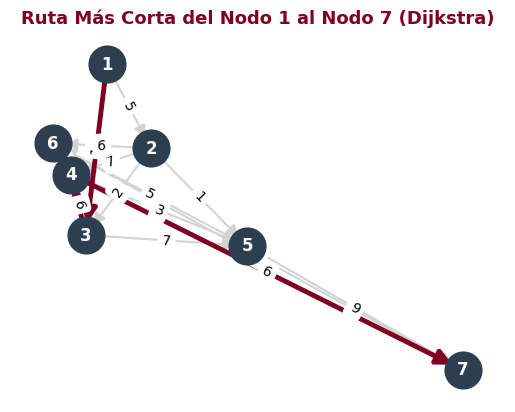

Resultados:
Secuencia de nodos a seguir: [1, 3, 4, 7]
Arcos recorridos: [(1, 3), (3, 4), (4, 7)]
Distacia minima: 13


In [26]:
#Dibujar todos los nodos
nx.draw_networkx_nodes(G_sp, pos, node_color='#2C3E50', node_size=700)
nx.draw_networkx_labels(G_sp, pos, font_color='white', font_weight='bold')

#Dibujar todas las flechas en gris
nx.draw_networkx_edges(G_sp, pos, edge_color='lightgray', arrows=True, arrowsize=18, width=1.5)

#Resaltar en color guinda las flechas del camino óptimo
nx.draw_networkx_edges(G_sp, pos, edgelist=aristas_ruta, edge_color='#800020', arrows=True, arrowsize=22, width=3.5)

#Dibujar etiquetas de los pesos
etiquetas_pesos = nx.get_edge_attributes(G_sp, 'weight')
nx.draw_networkx_edge_labels(G_sp, pos, edge_labels=etiquetas_pesos)

plt.title(f"Ruta Más Corta del Nodo {origen} al Nodo {destino} (Dijkstra)", fontsize=13, fontweight='bold', color='#800020')
plt.axis('off')
plt.show()


print(f"Resultados:")
print("Secuencia de nodos a seguir:", ruta_optima)
print("Arcos recorridos:", aristas_ruta)
print(f"Distacia minima: {distancia_total}")


# <font color="#800020">MODELO DE FLUJO MÁXIMO</font>

---

El **modelo de flujo máximo** busca determinar la mayor cantidad de flujo (material, tráfico, datos, fluidos, etc.) que puede circular desde un **nodo fuente** (origen) hasta un **nodo sumidero** (destino) a través de una red con capacidades finitas en sus arcos.

> **Objetivo clave:** Maximizar el flujo total transmitido desde la fuente hasta el sumidero respetando las capacidades residuales de cada arco.

---

### <font color="#2C3E50">Conceptos Fundamentales</font>

* **Capacidades $(C_{ij}, C_{ji})$:** Límite máximo de transporte en el arco $(i, j)$ desde $i$ hacia $j$, y viceversa.
* **Red Residual $(c_{ij}, c_{ji})$:** Estado de la red que muestra la capacidad remanente (disponible) en cada arco tras asignar flujo.
* **Ruta de Irrupción:** Trayectoria desde la fuente hasta el sumidero con capacidad residual estrictamente positiva ($c_{ij} > 0$).

---

### <font color="#2C3E50">Enumeración de Cortes</font>

Un **corte** define a un conjunto de arcos que, cuando se eliminan de la red, causan una interrupción total del flujo entre los nodos fuente y sumidero. La capacidad de corte es igual a la suma de las capacidades de los arcos correspondientes. Entre todos los cortes posibles en la red, el que tenga la **capacidad menor** permite el flujo máximo en la red.

---

### <font color="#2C3E50">Pasos del Algoritmo de Flujo Máximo</font>

1. **Paso 1 (Inicialización):** Para todos los arcos $(i, j)$ se iguala la capacidad residual con la capacidad inicial: $(c_{ij}, c_{ji}) = (C_{ij}, C_{ji})$. Se establece $a_1 = \infty$ y se etiqueta el nodo fuente $1$ con $[\infty, -]$. Se iguala $i = 1$ y se prosigue en el Paso 2.
2. **Paso 2 (Nodos alcanzables):** Determinar $S_i$, el conjunto de nodos $j$ no etiquetados que se pueden alcanzar directamente desde el nodo $i$, con arcos con residuales positivos ($c_{ij} > 0$). Si $S_i \neq \emptyset$, ir al Paso 3. En caso contrario, ir al Paso 4.
3. **Paso 3 (Etiquetado):** Determinar $k \in S_i$ tal que:
   $$c_{ik} = \max_{j \in S_i} \{c_{ij}\}$$
   Igualar $a_k = c_{ik}$ y etiquetar el nodo $k$ con $[a_k, i]$. Si $k = n$, el nodo sumidero se ha etiquetado y se ha encontrado una ruta de irrupción; ir al Paso 5. En caso contrario, igualar $i = k$ y seguir en el Paso 2.
4. **Paso 4 (Retroceso):** Si $i = 1$, no hay otras irrupciones posibles; ir al Paso 6. En caso contrario, sea $r$ el nodo que se ha etiquetado inmediatamente antes del nodo actual $i$ y quitar $i$ del conjunto de nodos adyacentes a $r$. Igualar $i = r$ y continuar en el Paso 2.
5. **Paso 5 (Determinación de la red residual):** Sea $N_p = (1, k_1, k_2, \dots, n)$ los nodos de la $p$-ésima ruta de irrupción del nodo fuente $1$ al nodo sumidero $n$. El flujo máximo por la ruta se calcula como:
   $$f_p = \min \{a_1, a_{k1}, a_{k2}, \dots, a_n\}$$
   La capacidad residual de cada arco a lo largo de la ruta de irrupción se disminuye en $f_p$ unidades en la dirección del flujo y se aumenta $f_p$ unidades en la dirección contraria:
   * $(c_{ij} - f_p, c_{ji} + f_p)$ si el flujo va de $i$ a $j$.
   * $(c_{ij} + f_p, c_{ji} - f_p)$ si el flujo va de $j$ a $i$.
   Se reinstalan todos los nodos que se hayan eliminado en el Paso 4. Poner $i = 1$ y regresar al Paso 2 para intentar una nueva ruta de irrupción.
6. **Paso 6 (Solución):**
   * Si se han determinado $m$ rutas de irrupción, el flujo máximo en la red es:
     $$F = f_1 + f_2 + \dots + f_m$$
   * Como los residuales inicial y final del arco $(i, j)$ se obtienen con $(C_{ij}, C_{ji})$ y $(c_{ij}, c_{ji})$ respectivamente, el flujo óptimo en el arco $(i, j)$ se calcula como:
     $$(\alpha_1, \alpha_2) = (C_{ij} - c_{ij}, C_{ji} - c_{ji})$$
     Si $\alpha_1 > 0$, el flujo óptimo de $i$ a $j$ es $\alpha_1$. Si $\alpha_2 > 0$, el flujo óptimo de $j$ a $i$ es $\alpha_2$.

<div style="background-color: #f8f9fa; border-left: 5px solid #800020; padding: 12px; margin: 10px 0; border-radius: 4px;">
<b>Aspectos Importantes:</b>
<ul>
  <li><b>Cancelación de Flujo:</b> Ajustar las capacidades en sentido contrario permite al algoritmo corregir asignaciones previas si descubre una mejor ruta global.</li>
  <li><b>Corte Mínimo:</b> El flujo máximo total alcanzable en la red siempre equivale a la capacidad del corte más pequeño.</li>
  <li><b>NetworkX:</b> Para implementar este algoritmo utilizaremos la función <code>nx.maximum_flow()</code>.</li>
</ul>
</div>

### <font color="#008080">Importar librerías e inicializar la red dirigida</font>

Cargamos las librerías principales, **`networkx`** para la construcción y análisis de la red, y **`matplotlib.pyplot`** para la graficación.

Utilizamos la función **`nx.DiGraph()`** para crear una estructura de **grafo dirigido**. Esto es esencial en el modelo de flujo máximo, ya que las capacidades de transporte tienen un sentido específico entre cada par de nodos (por ejemplo, del nodo fuente al nodo sumidero).

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

#Crear grafo dirigido para representar las capacidades residuales
G_mf = nx.DiGraph()

### <font color="#008080">Definimos y agregamos las capacidades de flujo</font>

Guardamos la estructura de la red en la lista `capacidades` mediante tuplas con la sintaxis **`(origen, destino, capacidad)`**.

Con el ciclo `for`, filtramos los arcos con capacidad positiva (`c > 0`) y los agregamos al grafo usando **`G_mf.add_edge(u, v, capacity=c)`**. Es fundamental asignar explícitamente el parámetro **`capacity`**, ya que es el atributo clave que requieren los algoritmos de flujo de NetworkX. Al final, el `print` confirma el número total de nodos y aristas cargados.



In [28]:
#Definición de capacidades dirigidas (Origen, Destino, Capacidad)
#Formato: (i, j, C_ij)
capacidades = [
    # Conexiones desde el nodo fuente (1)
    (1, 3, 14), (1, 5, 4), (1, 2, 8),

    # Conexiones desde el nodo 2
    (2, 3, 5), (3, 2, 10),
    (2, 5, 6),
    (2, 4, 7), (4, 2, 6),

    # Conexiones desde el nodo 3
    (3, 5, 10),
    (3, 4, 9), (4, 3, 7),

    # Conexiones hacia el nodo sumidero (5)
    (4, 5, 5)
]

In [29]:
#Agregar aristas con la propiedad 'capacity' requerida por NetworkX
for u, v, c in capacidades:
    if c > 0:  #Agregar solo capacidades mayores a cero
        G_mf.add_edge(u, v, capacity=c)

print(f"Red de flujo creada con {G_mf.number_of_nodes()} nodos y {G_mf.number_of_edges()} aristas dirigidas.")


Red de flujo creada con 5 nodos y 12 aristas dirigidas.





### <font color="#008080">Calcular el flujo máximo y arcos </font>

Establecemos el **nodo fuente** (`fuente = 1`) y el **nodo sumidero** (`sumidero = 5`).

* **`nx.maximum_flow()`**: Resuelve el modelo calculando tanto la capacidad máxima total (`flujo_valor`) como la distribución exacta del flujo que pasa por cada arco (`flujo_diccionario`).
* **Filtrado de arcos**: Mediante un ciclo recorremos la estructura del diccionario resultante para extraer únicamente las conexiones por las que realmente transita un flujo mayor a cero (`f > 0`), guardándolas en la lista `aristas_con_flujo`.

</div>

In [30]:
#Definir fuente (origen) y sumidero (destino)
fuente = 1
sumidero = 5

#Calcular el valor del flujo máximo y el diccionario de flujo por arco
flujo_valor, flujo_diccionario = nx.maximum_flow(G_mf, fuente, sumidero)

#Extraer arcos donde efectivamente circula flujo (> 0)
aristas_con_flujo = []
for u in flujo_diccionario:
    for v, f in flujo_diccionario[u].items():
        if f > 0:
            aristas_con_flujo.append((u, v, f))

print("Cálculo del flujo máximo")

Cálculo del flujo máximo


### <font color="#008080">Graficamos la red con el flujo óptimo y mostrar resultados</font>

* **Representación visual:** Con `nx.draw_networkx_nodes()` y `nx.draw_networkx_labels()` dibujamos los nodos en tono guinda con texto en blanco. Las conexiones inactivas se muestran en gris claro, mientras que las aristas de `arcos_activos` se resaltan en azul oscuro (`#2C3E50`) con mayor grosor.
* **Formato de etiquetas:** Recorremos la red para construir el diccionario `etiquetas_arcos`, desplegando sobre cada arco el par **`Flujo enviado / Capacidad total`**.
* **Reporte de datos:** Ocultamos los ejes con `plt.axis('off')`, desplegamos el gráfico y finalizamos imprimiendo un desglose detallado con el total de unidades transportadas y la carga individual asignada a cada tramo.


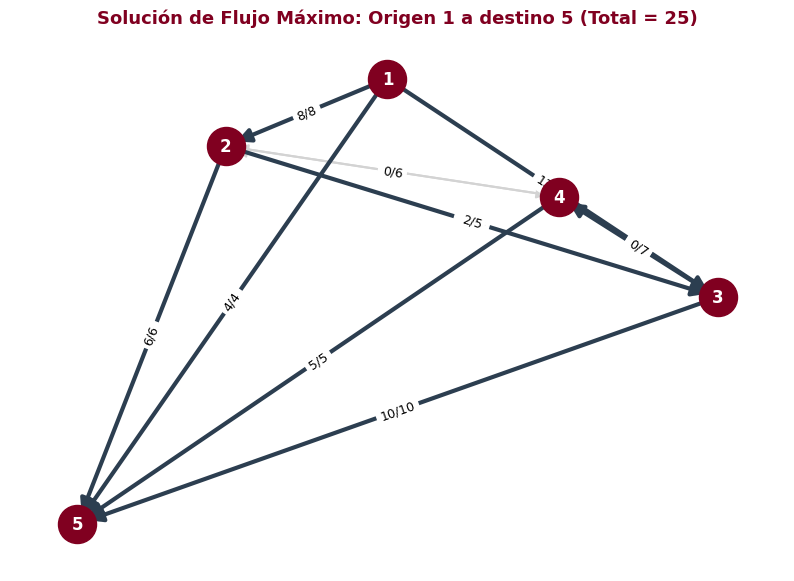

Flujo maximo en la red: 25 unidades
Distribucion del flujo por arco:
  Arco (1 -> 3): 13 / 14 unidades
  Arco (1 -> 5): 4 / 4 unidades
  Arco (1 -> 2): 8 / 8 unidades
  Arco (3 -> 5): 10 / 10 unidades
  Arco (3 -> 4): 5 / 9 unidades
  Arco (2 -> 3): 2 / 5 unidades
  Arco (2 -> 5): 6 / 6 unidades
  Arco (4 -> 5): 5 / 5 unidades


In [32]:
#Dibujamos la red mostrando (Flujo enviado / Capacidad total)
pos_mf = nx.spring_layout(G_mf, seed=42)

plt.figure(figsize=(10, 7))

#Dibujar nodos
nx.draw_networkx_nodes(G_mf, pos_mf, node_color='#800020', node_size=750)
nx.draw_networkx_labels(G_mf, pos_mf, font_color='white', font_weight='bold')

#Dibujar aristas base (gris)
nx.draw_networkx_edges(G_mf, pos_mf, edge_color='lightgray', arrows=True, arrowsize=15, width=1.5)

#Resaltar en azul arcos por los que circula flujo
arcos_activos = [(u, v) for u, v, f in aristas_con_flujo]
nx.draw_networkx_edges(G_mf, pos_mf, edgelist=arcos_activos, edge_color='#2C3E50', arrows=True, arrowsize=20, width=3.0)

#Crear etiquetas con formato "Flujo/Capacidad"
etiquetas_arcos = {}
for u, v, data in G_mf.edges(data=True):
    cap = data['capacity']
    flujo = flujo_diccionario[u].get(v, 0)
    etiquetas_arcos[(u, v)] = f"{flujo}/{cap}"

nx.draw_networkx_edge_labels(G_mf, pos_mf, edge_labels=etiquetas_arcos, font_size=9)

plt.title(f"Solución de Flujo Máximo: Origen {fuente} a destino {sumidero} (Total = {flujo_valor})",
          fontsize=13, fontweight='bold', color='#800020')
plt.axis('off')
plt.show()

# Imprimir resultados

print(f"Flujo maximo en la red: {flujo_valor} unidades")

print("Distribucion del flujo por arco:")
for u, v, f in aristas_con_flujo:
    cap = G_mf[u][v]['capacity']
    print(f"  Arco ({u} -> {v}): {f} / {cap} unidades")
